In [ ]:
from pathlib import Path

#  فولدر الصور
images_folder = r"/content/drive/MyDrive/merged2/images"

#  فولدر الليبلز
labels_folder = r"/content/drive/MyDrive/merged2/labels"


# امتدادات الصور
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

# عد الصور
image_count = sum(
    1 for file in Path(images_folder).iterdir()
    if file.suffix.lower() in image_extensions
)

# عد ملفات الليبل txt
label_count = sum(
    1 for file in Path(labels_folder).iterdir()
    if file.suffix.lower() == ".txt"
)

print(f"عدد الصور: {image_count}")
print(f"عدد ملفات الليبل: {label_count}")

عدد الصور: 2531
عدد ملفات الليبل: 2531



## ***YOLO Training Environment Setup***

In [ ]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

import os
import random
import shutil

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ***Preparing Dataset***


In [ ]:
# Original paths
original_images_path = "/content/drive/MyDrive/merged2/images"
original_labels_path = "/content/drive/MyDrive/merged2/labels"

# Split folder
split_base_path = "/content/drive/MyDrive/GP2_CLS26"

# train/val/test folders
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(split_base_path, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(split_base_path, 'labels', split), exist_ok=True)

In [ ]:
# gathering all images
image_files = [f for f in os.listdir(original_images_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
image_files = list(dict.fromkeys(image_files))
random.shuffle(image_files)


# Check labels for each image
valid_files = []
for img in image_files:
    lbl = os.path.splitext(img)[0] + ".txt"
    if os.path.exists(os.path.join(original_labels_path, lbl)):
        valid_files.append(img)
    else:
        print(f"No label for this image: {img}")

In [ ]:
# Splitting ratio : 70% 20% 10%
n = len(valid_files)
train_split = int(0.8 * n)
val_split = int(0.9 * n)

train_files = valid_files[:train_split]
val_files   = valid_files[train_split:val_split]
test_files  = valid_files[val_split:]

In [ ]:
def copy_files(file_list, split):
    for img_file in file_list:
        label_file = os.path.splitext(img_file)[0] + ".txt"


        src_img = os.path.join(original_images_path, img_file)
        src_lbl = os.path.join(original_labels_path, label_file)


        dst_img = os.path.join(split_base_path, 'images', split, img_file)
        dst_lbl = os.path.join(split_base_path, 'labels', split, label_file)

        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)


copy_files(train_files, 'train')
copy_files(val_files, 'val')
copy_files(test_files, 'test')

print(f"Data prepared in: {split_base_path}")
print(f"Train: {len(train_files)} images")
print(f"Validation: {len(val_files)} images")
print(f"Test: {len(test_files)} images")

Data prepared in: /content/drive/MyDrive/GP2_CLS26
Train: 2024 images
Validation: 253 images
Test: 254 images


In [ ]:
# YAML file

yaml_content = f"""
train: {split_base_path}/images/train
val: {split_base_path}/images/val
test: {split_base_path}/images/test
nc: 4
names: ["Clean", "Light", "Moderate", "Heavy"]
"""

with open("/content/drive/MyDrive/GP2_CLS26/GP2_CLS26.yaml", "w") as f:
    f.write(yaml_content.strip())

print("yaml created successfully.")

yaml created successfully.


##***YOLO Training***

In [ ]:
model = YOLO("yolo11n.pt")

model.train(data="/content/drive/MyDrive/GP2_CLS26/GP2_CLS26.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GP2_CLS26/GP2_CLS26.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad7ca14a270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
import shutil
from google.colab import files

# اسم الفولدر
folder_name = "/content/runs"

# اسم الملف المضغوط الناتج
zip_name = "runs_backup"

# ضغط الفولدر إلى ZIP
shutil.make_archive(zip_name, 'zip', folder_name)

# تحميل الملف على الجهاز
files.download(f"{zip_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.0±1.3 ms, read: 32.5±23.8 MB/s, size: 107.6 KB)
val: Scanning /content/drive/MyDrive/GP2_CLS26/labels/val... 253 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 253/253 125.8it/s 2.0s
val: New cache created: /content/drive/MyDrive/GP2_CLS26/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.0it/s 5.3s
                   all        253        253      0.591      0.686      0.713      0.708
                 Clean         75         75      0.716      0.893      0.894      0.888
                 Light         59         59       0.53      0.555       0.67      0.667
              Moderate         60         60      0.518      0.583      0.576      0.566
                 Heavy         59         59      0.599

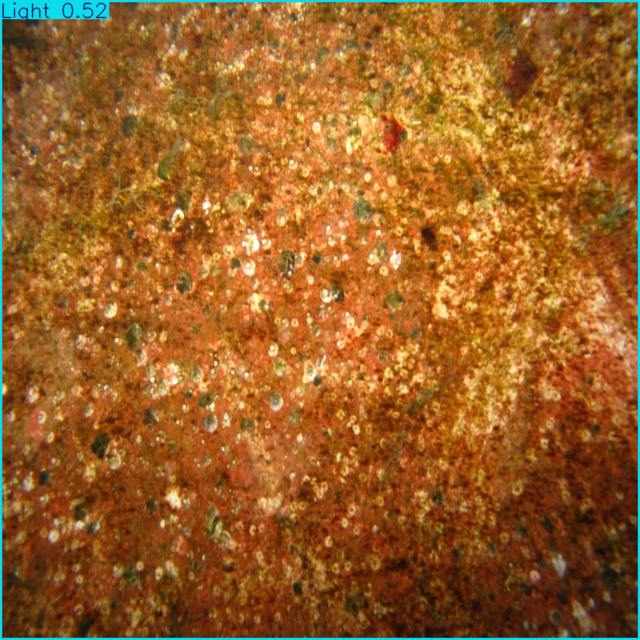

In [ ]:
# Validate
metrics = model.val()

# Test Inference
results = model(os.path.join(split_base_path, "images/test", test_files[0]))
results[0].show()

In [ ]:
# Confusion Matrix
metrics.confusion_matrix.plot()
print(metrics)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad8fe81f560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
# Load your trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Evaluate on test set
metrics = model.val(data="/content/drive/MyDrive/GP2_CLS26/GP2_CLS26.yaml", split="test")

print(metrics)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 25.8±52.7 ms, read: 24.3±33.4 MB/s, size: 135.6 KB)
val: Scanning /content/drive/MyDrive/GP2_CLS26/labels/test... 254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 254/254 122.4it/s 2.1s
val: New cache created: /content/drive/MyDrive/GP2_CLS26/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.5it/s 6.3s
                   all        254        254       0.58      0.706      0.731      0.726
                 Clean         70         70      0.643      0.971      0.902      0.902
                 Light         52         52      0.441      0.462      0.534      0.534
              Moderate         63         63      0.544      0.651      0.692      0.685
                 Heavy         69         69      0